# Statistics for Machine Learning — Deep Mastery Notebook 04

# Sampling, Confidence Intervals, and Hypothesis Testing  
## Learn the concepts, learn the calculations, and learn **how to think**

This notebook is a deeply expanded teaching version of:

> **Stats ML Notebook 04 — Sampling, Confidence Intervals, and Hypothesis Testing**

The original notebook introduced the essential topics. This notebook preserves that same foundation and adds a complete reasoning system so that you can:

- recognize what kind of statistical problem you are facing;
- understand what every formula is trying to measure;
- choose an appropriate method;
- calculate the answer manually and with Python;
- interpret the statistic, confidence interval, and p-value correctly;
- connect statistical reasoning to machine learning and A/B testing;
- identify assumptions and common mistakes;
- solve unfamiliar questions instead of memorizing isolated formulas.

---

## The central story of this notebook

We usually want to know something about a **population**, but we only observe a **sample**.

Because a different sample would give a different answer, every sample result has uncertainty.

Statistics gives us two major tools:

### Estimation

> What population values are reasonable based on the sample?

This leads to **confidence intervals**.

### Testing

> Is the sample result too unusual under a particular population claim?

This leads to **hypothesis tests, test statistics, and p-values**.

---

## How each major concept is taught

For every important idea, look for:

1. **Meaning** — what it says in simple language  
2. **Mental picture** — how to imagine it  
3. **Formula translation** — what each part means  
4. **Worked example** — calculation step by step  
5. **Python implementation** — how to compute it  
6. **Output interpretation** — what the number is telling us  
7. **Common mistakes** — what not to say  
8. **Think and solve** — guided questions

> The goal is not to memorize statistics.  
> The goal is to learn the reasoning pattern behind statistics.

# 0. The Universal Statistical Thinking Framework

Before using any formula, answer these seven questions.

## STEP 1 — What is the population question?

Examples:

- What is the true average customer spending?
- Is the new website's conversion rate higher?
- Did the same patients improve after treatment?
- Are customer segment and churn associated?
- Is one ML model genuinely better?

## STEP 2 — What is the population parameter?

A parameter is the unknown population quantity.

| Question | Parameter |
|---|---|
| Average spending | Population mean \(\mu\) |
| Conversion rate | Population proportion \(p\) |
| Difference between group means | \(\mu_B-\mu_A\) |
| Average before/after change | Mean difference \(\mu_d\) |
| Difference in conversion rates | \(p_B-p_A\) |
| Association between categories | Population association |

## STEP 3 — What data structure do I have?

Ask:

- Numerical or categorical?
- One sample or two groups?
- Independent groups or the same subjects twice?
- Mean, proportion, median, correlation, or another statistic?

## STEP 4 — What uncertainty must be measured?

Your estimate changes across samples.  
The **standard error** describes that sample-to-sample uncertainty.

## STEP 5 — Am I estimating or testing?

- **Estimate** → confidence interval
- **Test a claim** → hypothesis test
- Often report both.

## STEP 6 — What assumptions make the method trustworthy?

Typical checks:

- random or representative sampling;
- independent observations;
- appropriate sample size;
- no destructive outliers for a mean-based method;
- correct pairing or independence;
- expected counts large enough for chi-square;
- no uncontrolled repeated testing.

## STEP 7 — What is the practical conclusion?

A complete conclusion contains:

1. observed estimate;
2. uncertainty or test result;
3. direction and size of effect;
4. statistical conclusion;
5. practical meaning;
6. limitations.

---

## The shortest memory version

> **Question → parameter → data structure → uncertainty → method → assumptions → conclusion**

## One map connecting the whole notebook

```text
Population
   ↓ take one random sample
Sample
   ↓ calculate a statistic
Sample mean / proportion / difference
   ↓ ask how much it changes across possible samples
Sampling distribution
   ↓ measure its spread
Standard error
   ↓ two possible goals
   ├── Estimate population value → Confidence interval
   └── Test population claim     → Test statistic → p-value
```

Everything in this notebook belongs somewhere on this map.

# 1. Setup

The examples use reproducible simulated data so that the true population values are known.  
In real work, population values are usually unknown.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import (
    norm,
    t,
    ttest_1samp,
    ttest_ind,
    ttest_rel,
    chi2_contingency,
    mannwhitneyu,
    wilcoxon,
)

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Setup complete.")

Setup complete.


Population size: 200000
Population mean: 51.76
Population median: 40.36
Population standard deviation: 41.85


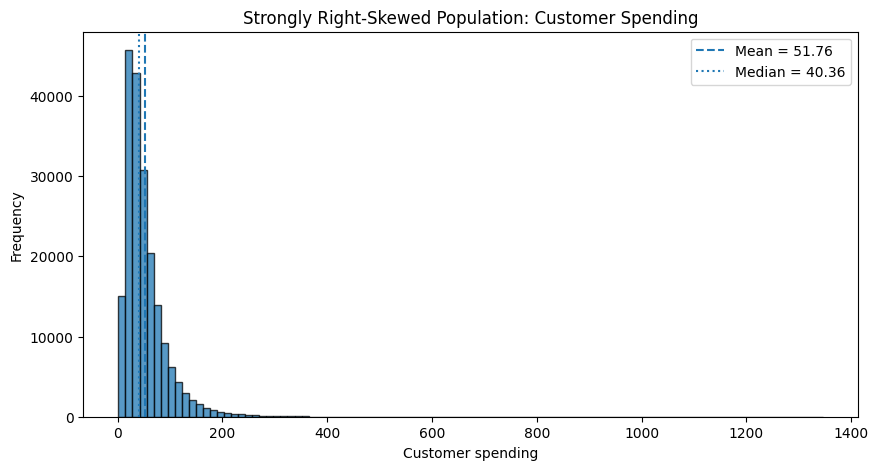

In [2]:
# A large, strongly right-skewed customer-spending population

population_size = 200_000

population_spend = rng.lognormal(
    mean=3.7,
    sigma=0.7,
    size=population_size
)

population_mean = population_spend.mean()
population_median = np.median(population_spend)
population_std = population_spend.std(ddof=0)

print("Population size:", population_size)
print("Population mean:", round(population_mean, 2))
print("Population median:", round(population_median, 2))
print("Population standard deviation:", round(population_std, 2))

plt.figure(figsize=(10, 5))
plt.hist(population_spend, bins=100, edgecolor="black", alpha=0.75)
plt.axvline(population_mean, linestyle="--", label=f"Mean = {population_mean:.2f}")
plt.axvline(population_median, linestyle=":", label=f"Median = {population_median:.2f}")
plt.title("Strongly Right-Skewed Population: Customer Spending")
plt.xlabel("Customer spending")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## What should you notice?

The population is clearly not normal.

- Most customers spend moderate amounts.
- A smaller number spend very large amounts.
- Those large values pull the mean to the right.
- Therefore, the population mean is higher than the population median.

This population will help us understand an important fact:

> The original data can be skewed while the distribution of sufficiently large sample means becomes approximately normal.

# 2. Population, Sample, Parameter, and Statistic

These four words must remain separate.

## Population

The complete group we want to understand.

Examples:

- all current customers;
- all future transactions;
- all patients who could receive a treatment;
- all future images presented to an ML model.

## Parameter

A fixed but usually unknown numerical property of the population.

Examples:

- population mean \(\mu\);
- population proportion \(p\);
- population mean difference \(\mu_B-\mu_A\).

## Sample

The observations actually collected.

## Statistic

A number calculated from the sample.

Examples:

- sample mean \(\bar{x}\);
- sample proportion \(\hat p\);
- sample mean difference \(\bar{x}_B-\bar{x}_A\).

---

## Important relationship

We use a **statistic** to estimate a **parameter**.

\[
\bar{x}\quad\text{estimates}\quad\mu
\]

\[
\hat p\quad\text{estimates}\quad p
\]

The statistic changes from sample to sample.  
The population parameter does not change.

In [3]:
sample_size = 500
sample = rng.choice(population_spend, size=sample_size, replace=False)

sample_mean = sample.mean()
sample_median = np.median(sample)
sample_std = sample.std(ddof=1)

comparison = pd.DataFrame({
    "Quantity": [
        "Mean",
        "Median",
        "Standard deviation"
    ],
    "Population": [
        population_mean,
        population_median,
        population_std
    ],
    "One sample": [
        sample_mean,
        sample_median,
        sample_std
    ]
})

comparison

,Quantity,Population,One sample
0,Mean,51.7643,51.1494
1,Median,40.3636,38.4562
2,Standard deviation,41.8470,41.7665


## How to interpret this table

The sample values are usually close to the corresponding population values, but they are not exactly equal.

That difference is not automatically an error.

It is a natural consequence of selecting only part of the population.

This is called **sampling variation**.

# 3. Sampling Variation

## Meaning

If we repeatedly select samples from the same population, each sample contains different observations.

Therefore, each sample produces a somewhat different statistic.

For example:

```text
Sample 1 mean = 50.8
Sample 2 mean = 52.1
Sample 3 mean = 49.7
Sample 4 mean = 51.4
```

The population has not changed.  
The sample means differ because the samples differ.

> Sampling variation is the natural variation in a statistic caused by random sampling.

In [4]:
sample_size = 100
sample_records = []

for sample_id in range(1, 11):
    current_sample = rng.choice(
        population_spend,
        size=sample_size,
        replace=False
    )

    sample_records.append({
        "sample_id": sample_id,
        "sample_mean": current_sample.mean(),
        "sample_median": np.median(current_sample)
    })

ten_samples_df = pd.DataFrame(sample_records)
ten_samples_df

,sample_id,sample_mean,sample_median
0,1,57.0914,42.5801
1,2,48.9651,38.3814
2,3,54.5492,39.1926
3,4,47.6161,42.8266
4,5,46.0316,36.5830
5,6,51.0564,37.9286
6,7,59.5226,43.0083
7,8,57.4705,44.8313
8,9,54.2133,37.4390
9,10,57.6635,38.1537


## Think like a statistician

Do not ask:

> Why are these sample means not identical?

Ask:

> Is the amount of variation reasonable for samples of this size?

That question leads to the **sampling distribution** and **standard error**.

# 4. Sampling Distribution

## Meaning

A sampling distribution is the distribution of a statistic across all possible samples of a fixed size.

For the sample mean:

1. take a random sample of size \(n\);
2. calculate its mean;
3. repeat many times;
4. collect all those means.

The resulting distribution is called the **sampling distribution of the sample mean**.

---

## Important distinction

These are two different distributions:

### Distribution of individual observations

```text
All individual customer spending values
```

### Sampling distribution of the mean

```text
All means obtained from repeated samples
```

The original observations may be highly skewed while the sample means are much more normal.

True population mean: 51.764
Mean of simulated sample means: 51.827
Spread of sample means: 4.19


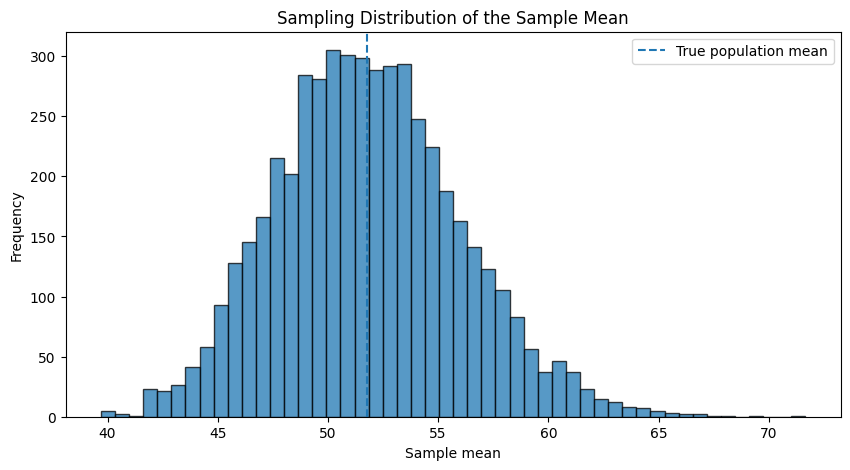

In [5]:
sample_size = 100
n_repetitions = 5_000

sample_means = np.empty(n_repetitions)

for i in range(n_repetitions):
    current_sample = rng.choice(
        population_spend,
        size=sample_size,
        replace=False
    )
    sample_means[i] = current_sample.mean()

print("True population mean:", round(population_mean, 3))
print("Mean of simulated sample means:", round(sample_means.mean(), 3))
print("Spread of sample means:", round(sample_means.std(ddof=1), 3))

plt.figure(figsize=(10, 5))
plt.hist(sample_means, bins=50, edgecolor="black", alpha=0.75)
plt.axvline(population_mean, linestyle="--", label="True population mean")
plt.title("Sampling Distribution of the Sample Mean")
plt.xlabel("Sample mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## What is the center of the sampling distribution?

The expected value of the sample mean is the population mean:

\[
E(\bar X)=\mu
\]

This means the sample mean is an **unbiased estimator** of the population mean under random sampling.

It does not mean every sample mean equals \(\mu\).

It means that across repeated random samples, sample means balance around \(\mu\).

# 5. Standard Deviation versus Standard Error

This distinction is essential.

## Standard deviation

Standard deviation describes how spread out **individual observations** are.

Question answered:

> How different are individual customers from one another?

## Standard error

Standard error describes how spread out **sample estimates** are across possible samples.

Question answered:

> How much would the sample mean change if we repeated the study?

For a sample mean:

\[
SE_{\bar{x}}=\frac{s}{\sqrt n}
\]

where:

- \(s\) = sample standard deviation;
- \(n\) = sample size;
- \(SE_{\bar{x}}\) = estimated standard error of the sample mean.

---

## Mental picture

```text
Standard deviation:
individual values around their sample mean

Standard error:
possible sample means around the population mean
```

In [6]:
sample_size = 100

one_sample = rng.choice(
    population_spend,
    size=sample_size,
    replace=False
)

sample_sd = one_sample.std(ddof=1)
se_formula = sample_sd / np.sqrt(sample_size)
se_simulated = sample_means.std(ddof=1)

print("Sample standard deviation:", round(sample_sd, 3))
print("Standard error using formula:", round(se_formula, 3))
print("Standard error from simulation:", round(se_simulated, 3))

Sample standard deviation: 40.675
Standard error using formula: 4.068
Standard error from simulation: 4.19


## How to read the result

If the standard deviation is 40, this means individual observations vary substantially.

If the standard error is 4, this means sample means of this size typically vary much less than individual observations.

Averages are more stable than individual values because high and low observations partly balance one another.

## Why does larger \(n\) reduce standard error?

\[
SE=\frac{s}{\sqrt n}
\]

If sample size increases:

- the denominator becomes larger;
- the standard error becomes smaller;
- the sample mean becomes more precise;
- the confidence interval becomes narrower;
- a hypothesis test can detect smaller effects.

But notice the square root:

- multiplying \(n\) by 4 approximately halves the standard error;
- multiplying \(n\) by 9 approximately divides the standard error by 3.

To reduce uncertainty substantially, we often need much more data.

In [7]:
sample_sizes = [10, 25, 50, 100, 250, 500, 1_000]
rows = []

for n in sample_sizes:
    simulated_means = []

    for _ in range(1_500):
        current_sample = rng.choice(
            population_spend,
            size=n,
            replace=False
        )
        simulated_means.append(current_sample.mean())

    rows.append({
        "sample_size": n,
        "simulated_standard_error": np.std(simulated_means, ddof=1),
        "theoretical_standard_error": population_std / np.sqrt(n)
    })

se_df = pd.DataFrame(rows)
se_df

,sample_size,simulated_standard_error,theoretical_standard_error
0,10,13.3302,13.2332
1,25,8.5054,8.3694
2,50,5.8167,5.9181
3,100,4.1443,4.1847
4,250,2.7051,2.6466
5,500,1.7952,1.8715
6,1000,1.3161,1.3233


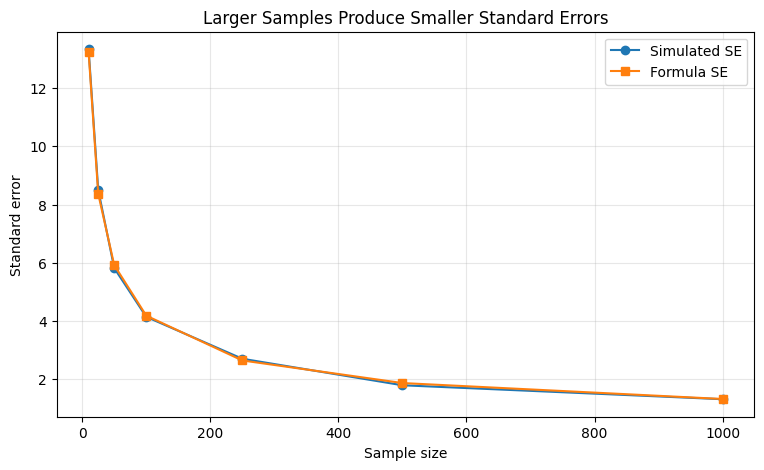

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(
    se_df["sample_size"],
    se_df["simulated_standard_error"],
    marker="o",
    label="Simulated SE"
)
plt.plot(
    se_df["sample_size"],
    se_df["theoretical_standard_error"],
    marker="s",
    label="Formula SE"
)
plt.title("Larger Samples Produce Smaller Standard Errors")
plt.xlabel("Sample size")
plt.ylabel("Standard error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Central Limit Theorem — Deep Understanding

## The theorem

When observations are independent and the population has a finite mean and variance, the sampling distribution of the sample mean becomes approximately normal as sample size becomes sufficiently large.

Symbolically:

\[
\bar X \approx N\left(\mu,\frac{\sigma}{\sqrt n}\right)
\]

This tells us two things:

### Center

\[
E(\bar X)=\mu
\]

### Spread

\[
SD(\bar X)=\frac{\sigma}{\sqrt n}
\]

---

## What becomes normal?

The **sampling distribution of the mean** becomes approximately normal.

## What does not necessarily become normal?

The original individual observations do not become normal.

Customer spending can remain strongly right-skewed.

---

## Why is the CLT useful?

Once the sampling distribution is approximately normal, we know how likely different distances from the center are.

For example, approximately 95% of a normal distribution lies within about 1.96 standard deviations of its mean.

For a sampling distribution, the relevant spread is the **standard error**.

This gives the logic behind:

- confidence intervals;
- z-tests and large-sample t-tests;
- p-values for mean-based statistics;
- uncertainty around many ML metrics.

---

## Important caution

There is no universal guarantee that \(n=30\) is always enough.

The sample size needed depends on:

- amount of skewness;
- heaviness of tails;
- presence of extreme outliers;
- dependence between observations;
- the statistic being studied.

Extremely heavy-tailed or dependent data may require special methods.

In [9]:
def simulate_sampling_distribution(sample_size, repetitions=3_000):
    means = np.empty(repetitions)

    for i in range(repetitions):
        current_sample = rng.choice(
            population_spend,
            size=sample_size,
            replace=False
        )
        means[i] = current_sample.mean()

    return means

means_n5 = simulate_sampling_distribution(5)
means_n30 = simulate_sampling_distribution(30)
means_n200 = simulate_sampling_distribution(200)

for n, means in [(5, means_n5), (30, means_n30), (200, means_n200)]:
    print(
        f"n={n:>3} | mean={means.mean():.3f} "
        f"| SE={means.std(ddof=1):.3f} "
        f"| skewness={stats.skew(means):.3f}"
    )

n=  5 | mean=51.693 | SE=18.857 | skewness=1.320
n= 30 | mean=51.861 | SE=7.652 | skewness=0.552
n=200 | mean=51.770 | SE=2.979 | skewness=0.272


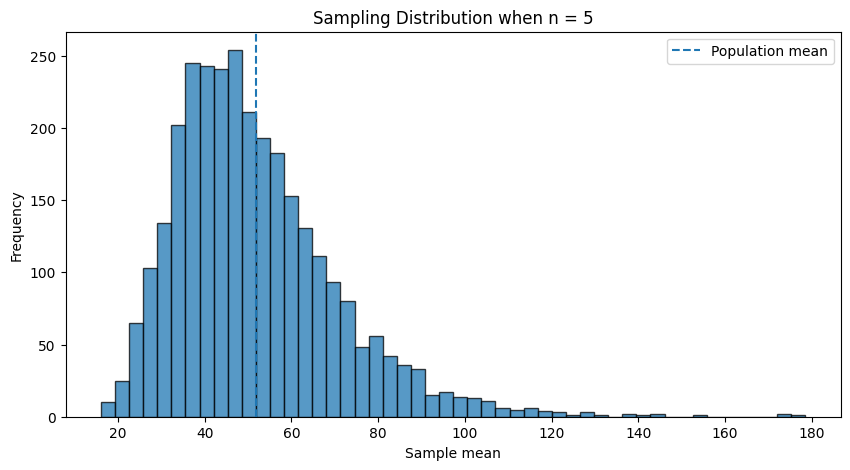

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(means_n5, bins=50, edgecolor="black", alpha=0.75)
plt.axvline(population_mean, linestyle="--", label="Population mean")
plt.title("Sampling Distribution when n = 5")
plt.xlabel("Sample mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

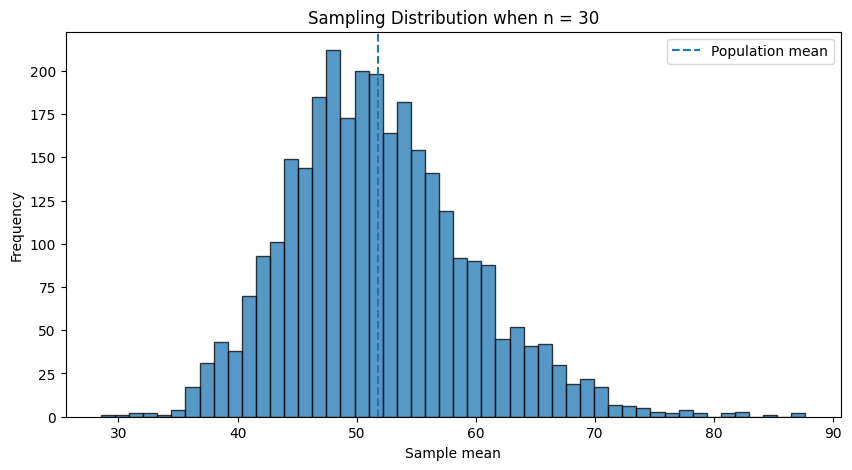

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(means_n30, bins=50, edgecolor="black", alpha=0.75)
plt.axvline(population_mean, linestyle="--", label="Population mean")
plt.title("Sampling Distribution when n = 30")
plt.xlabel("Sample mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

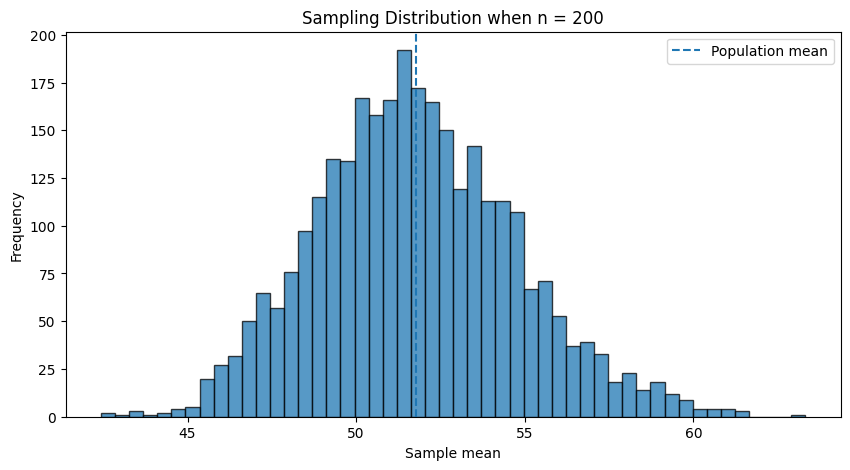

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(means_n200, bins=50, edgecolor="black", alpha=0.75)
plt.axvline(population_mean, linestyle="--", label="Population mean")
plt.title("Sampling Distribution when n = 200")
plt.xlabel("Sample mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## What should you conclude?

As \(n\) increases:

- the sampling distribution becomes more symmetric and normal-looking;
- its center remains near the population mean;
- its spread becomes smaller;
- sample means become more stable.

This is the bridge from skewed real data to normal-based inference.

# 7. From the Central Limit Theorem to a Confidence Interval

This connection is often memorized but not understood.

## Step 1 — Start with one observed sample mean

Suppose:

\[
\bar{x}=50
\]

This is our point estimate of the unknown population mean.

## Step 2 — Measure the uncertainty of that estimate

Suppose:

\[
SE=2
\]

This says sample means of this size typically vary by about 2 units across samples.

## Step 3 — Use the shape of the sampling distribution

If the sampling distribution is approximately normal, about 95% of sample means fall within approximately 1.96 standard errors of the true mean.

## Step 4 — Reverse the reasoning

If sample means usually fall within \(1.96SE\) of \(\mu\), then the interval:

\[
\bar{x}\pm1.96SE
\]

will capture \(\mu\) in approximately 95% of repeated samples.

That is the logic of the confidence interval.

# 8. Confidence Interval for a Mean

The general form is:

\[
\text{estimate}\pm\text{margin of error}
\]

For a mean when population standard deviation is unknown:

\[
\bar{x}\pm t^*\frac{s}{\sqrt n}
\]

where:

- \(\bar{x}\) = one observed sample mean;
- \(s\) = sample standard deviation;
- \(n\) = sample size;
- \(s/\sqrt n\) = standard error;
- \(t^*\) = t critical value;
- \(t^*\times SE\) = margin of error.

---

## Very important correction

The confidence interval does **not** calculate the center.

The center is already the sample mean:

\[
\text{center}=\bar{x}
\]

The confidence interval calculates a range around that center to represent uncertainty about \(\mu\).

In [13]:
# One observed sample

ci_sample_size = 120
ci_sample = rng.choice(
    population_spend,
    size=ci_sample_size,
    replace=False
)

x_bar = ci_sample.mean()
s = ci_sample.std(ddof=1)
n = len(ci_sample)

se = s / np.sqrt(n)
degrees_of_freedom = n - 1
confidence_level = 0.95

t_critical = t.ppf(
    (1 + confidence_level) / 2,
    df=degrees_of_freedom
)

margin_of_error = t_critical * se

lower = x_bar - margin_of_error
upper = x_bar + margin_of_error

result = pd.Series({
    "sample mean": x_bar,
    "sample standard deviation": s,
    "sample size": n,
    "standard error": se,
    "t critical value": t_critical,
    "margin of error": margin_of_error,
    "lower limit": lower,
    "upper limit": upper,
    "true population mean": population_mean,
})

result

sample mean                  50.1993
sample standard deviation    39.4010
sample size                 120.0000
standard error                3.5968
t critical value              1.9801
margin of error               7.1220
lower limit                  43.0773
upper limit                  57.3213
true population mean         51.7643
dtype: float64

## How to narrate the calculation

1. The sample mean is the center of the interval.
2. The standard error measures uncertainty in that mean.
3. The critical value chooses how much of the sampling distribution to cover.
4. Their product is the margin of error.
5. Subtract and add the margin of error to form the interval.

A strong interpretation is:

> The sample mean is \(\bar{x}\). Using a 95% t confidence interval, plausible values for the population mean range from the lower limit to the upper limit.

Do not say:

> There is a 95% probability that this fixed interval contains the fixed population mean.

The frequentist meaning is about the long-run performance of the interval-building procedure.

In [14]:
# Verify with SciPy

scipy_lower, scipy_upper = t.interval(
    confidence=0.95,
    df=n - 1,
    loc=x_bar,
    scale=se
)

print("Manual CI:", (round(lower, 3), round(upper, 3)))
print("SciPy CI:", (round(scipy_lower, 3), round(scipy_upper, 3)))

Manual CI: (np.float64(43.077), np.float64(57.321))
SciPy CI: (np.float64(43.077), np.float64(57.321))


# 9. What Controls Confidence Interval Width?

A confidence interval becomes wider when uncertainty increases.

## Wider interval

- higher confidence level;
- smaller sample size;
- greater data variability;
- more conservative or robust procedure.

## Narrower interval

- lower confidence level;
- larger sample size;
- lower variability.

---

## Trade-off

Higher confidence requires a wider interval.

You cannot usually demand both:

- extremely high confidence;
- extremely narrow uncertainty;

without collecting more data.

In [15]:
confidence_levels = [0.80, 0.90, 0.95, 0.99]
rows = []

for level in confidence_levels:
    critical = t.ppf((1 + level) / 2, df=n - 1)
    margin = critical * se

    rows.append({
        "confidence_level": level,
        "critical_value": critical,
        "margin_of_error": margin,
        "lower": x_bar - margin,
        "upper": x_bar + margin,
        "width": 2 * margin
    })

confidence_width_df = pd.DataFrame(rows)
confidence_width_df

,confidence_level,critical_value,margin_of_error,lower,upper,width
0,0.8000,1.2887,4.6352,45.5641,54.8345,9.2704
1,0.9000,1.6578,5.9626,44.2367,56.1619,11.9253
2,0.9500,1.9801,7.1220,43.0773,57.3213,14.2440
3,0.9900,2.6178,9.4156,40.7837,59.6149,18.8312


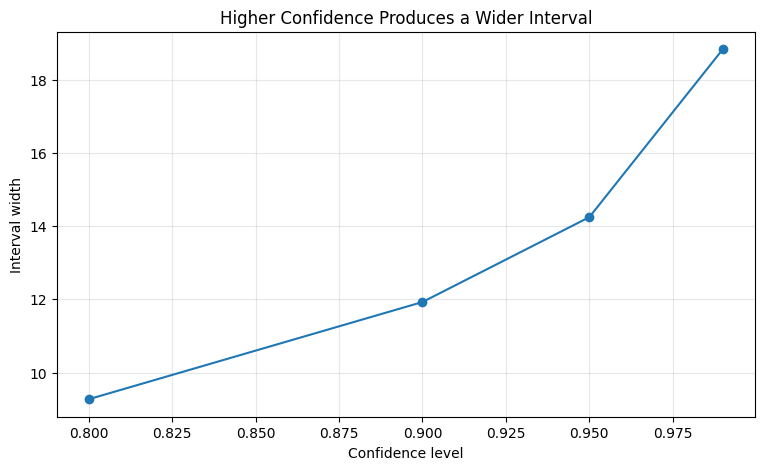

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(
    confidence_width_df["confidence_level"],
    confidence_width_df["width"],
    marker="o"
)
plt.title("Higher Confidence Produces a Wider Interval")
plt.xlabel("Confidence level")
plt.ylabel("Interval width")
plt.grid(alpha=0.3)
plt.show()

## Sample-size planning idea

For an approximate z-based interval for a mean:

\[
ME=z^*\frac{\sigma}{\sqrt n}
\]

Solving for \(n\):

\[
n=\left(\frac{z^*\sigma}{ME}\right)^2
\]

This estimates how many observations are needed to achieve a desired margin of error.

Always round sample size upward.

In [17]:
desired_margin = 2.0
estimated_sigma = population_std
z_critical = norm.ppf(0.975)

required_n = (z_critical * estimated_sigma / desired_margin) ** 2

print("Raw required sample size:", required_n)
print("Rounded-up required sample size:", int(np.ceil(required_n)))

Raw required sample size: 1681.7621470770755
Rounded-up required sample size: 1682


# 10. Confidence Interval Coverage

A 95% confidence method is designed so that:

> Across many repeated samples, approximately 95% of the constructed intervals contain the true population parameter.

A particular interval either contains the true value or it does not.

The 95% describes the reliability of the **procedure**, not a probability assigned after the specific interval has been calculated.

In [18]:
n_intervals = 500
coverage_sample_size = 100

interval_records = []

for interval_id in range(n_intervals):
    current_sample = rng.choice(
        population_spend,
        size=coverage_sample_size,
        replace=False
    )

    current_mean = current_sample.mean()
    current_sd = current_sample.std(ddof=1)
    current_se = current_sd / np.sqrt(coverage_sample_size)
    current_critical = t.ppf(
        0.975,
        df=coverage_sample_size - 1
    )

    current_lower = current_mean - current_critical * current_se
    current_upper = current_mean + current_critical * current_se

    interval_records.append({
        "interval_id": interval_id,
        "mean": current_mean,
        "lower": current_lower,
        "upper": current_upper,
        "contains_true_mean": (
            current_lower <= population_mean <= current_upper
        )
    })

coverage_df = pd.DataFrame(interval_records)
observed_coverage = coverage_df["contains_true_mean"].mean()

print("Observed coverage:", round(observed_coverage, 3))

Observed coverage: 0.948


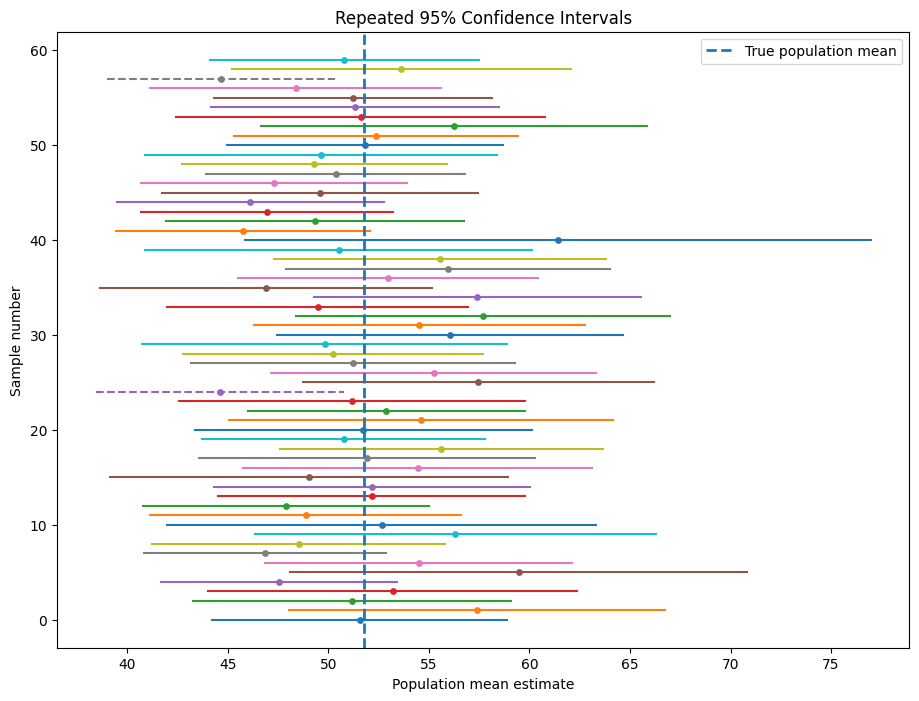

In [19]:
first_intervals = coverage_df.head(60)

plt.figure(figsize=(11, 8))

for _, row in first_intervals.iterrows():
    line_style = "-" if row["contains_true_mean"] else "--"

    plt.plot(
        [row["lower"], row["upper"]],
        [row["interval_id"], row["interval_id"]],
        linestyle=line_style
    )

    plt.scatter(row["mean"], row["interval_id"], s=15)

plt.axvline(
    population_mean,
    linestyle="--",
    linewidth=2,
    label="True population mean"
)

plt.title("Repeated 95% Confidence Intervals")
plt.xlabel("Population mean estimate")
plt.ylabel("Sample number")
plt.legend()
plt.show()

# 11. Confidence Interval for a Proportion

A proportion is a rate between 0 and 1.

Examples:

- conversion rate;
- churn rate;
- fraud rate;
- click-through rate;
- model accuracy.

The sample proportion is:

\[
\hat p=\frac{x}{n}
\]

where \(x\) is the number of successes.

An approximate standard error is:

\[
SE_{\hat p}=\sqrt{\frac{\hat p(1-\hat p)}{n}}
\]

An approximate 95% confidence interval is:

\[
\hat p\pm1.96SE_{\hat p}
\]

This simple Wald interval is best used when success and failure counts are not small.  
For small or extreme proportions, Wilson or exact methods are often safer.

In [20]:
n_users = 2_000
conversions = 126

p_hat = conversions / n_users
se_p = np.sqrt(p_hat * (1 - p_hat) / n_users)
z_critical = norm.ppf(0.975)

p_lower = p_hat - z_critical * se_p
p_upper = p_hat + z_critical * se_p

print("Observed conversion rate:", round(p_hat, 4))
print("Standard error:", round(se_p, 4))
print("95% CI:", (round(p_lower, 4), round(p_upper, 4)))
print(
    "Percentage form:",
    (round(100 * p_lower, 2), round(100 * p_upper, 2))
)

Observed conversion rate: 0.063
Standard error: 0.0054
95% CI: (np.float64(0.0524), np.float64(0.0736))
Percentage form: (np.float64(5.24), np.float64(7.36))


## Interpretation

A strong business interpretation is:

> The observed conversion rate is 6.3%. Sampling uncertainty suggests the true conversion rate is plausibly within the reported interval.

The interval communicates more than the point estimate alone.

A conversion rate of 6.3% based on 100 users is much less precise than 6.3% based on 100,000 users.

# 12. Confidence Interval for Model Accuracy

Accuracy is also a proportion:

\[
\text{accuracy}=\frac{\text{correct predictions}}{\text{test observations}}
\]

Therefore, a confidence interval can express uncertainty around test accuracy.

Important assumptions and cautions:

- test observations should represent future deployment data;
- observations should be reasonably independent;
- the test set must not have been repeatedly used for model selection;
- distribution shift is not captured by a standard confidence interval;
- overlapping accuracy intervals alone are not a formal paired model-comparison test.

In [21]:
n_test = 1_000
correct_predictions = 850

accuracy = correct_predictions / n_test
se_accuracy = np.sqrt(
    accuracy * (1 - accuracy) / n_test
)

accuracy_lower = accuracy - z_critical * se_accuracy
accuracy_upper = accuracy + z_critical * se_accuracy

print("Observed test accuracy:", round(accuracy, 3))
print(
    "Approximate 95% CI:",
    (round(accuracy_lower, 3), round(accuracy_upper, 3))
)

Observed test accuracy: 0.85
Approximate 95% CI: (np.float64(0.828), np.float64(0.872))


# 13. Bootstrap Confidence Intervals

## Why bootstrap?

Some statistics do not have a simple standard-error formula.

Examples:

- median;
- trimmed mean;
- correlation;
- difference in F1 score;
- custom business metric.

Bootstrap estimates uncertainty by resampling from the observed sample.

## Algorithm

1. Begin with one observed sample of size \(n\).
2. Draw a new sample of size \(n\) **with replacement**.
3. Calculate the statistic.
4. Repeat many times.
5. Use percentiles of the bootstrap statistics as interval limits.

---

## Why with replacement?

Sampling with replacement allows each bootstrap sample to mimic the variation we might see if we collected another sample from the underlying population.

Some original observations appear more than once.  
Some do not appear in a particular bootstrap sample.

---

## Important limitation

Bootstrap treats the observed sample as a stand-in for the population.

If the original sample is biased or unrepresentative, bootstrap repeats that bias.  
Bootstrap does not repair bad sampling.

In [22]:
bootstrap_original = rng.choice(
    population_spend,
    size=250,
    replace=False
)

n_bootstrap = 5_000
bootstrap_means = np.empty(n_bootstrap)
bootstrap_medians = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    bootstrap_sample = rng.choice(
        bootstrap_original,
        size=len(bootstrap_original),
        replace=True
    )

    bootstrap_means[i] = bootstrap_sample.mean()
    bootstrap_medians[i] = np.median(bootstrap_sample)

mean_ci = np.percentile(bootstrap_means, [2.5, 97.5])
median_ci = np.percentile(bootstrap_medians, [2.5, 97.5])

print("Original sample mean:", round(bootstrap_original.mean(), 3))
print("Bootstrap mean CI:", tuple(np.round(mean_ci, 3)))
print()
print("Original sample median:", round(np.median(bootstrap_original), 3))
print("Bootstrap median CI:", tuple(np.round(median_ci, 3)))

Original sample mean: 51.951
Bootstrap mean CI: (np.float64(47.258), np.float64(56.911))

Original sample median: 40.324
Bootstrap median CI: (np.float64(36.476), np.float64(45.556))


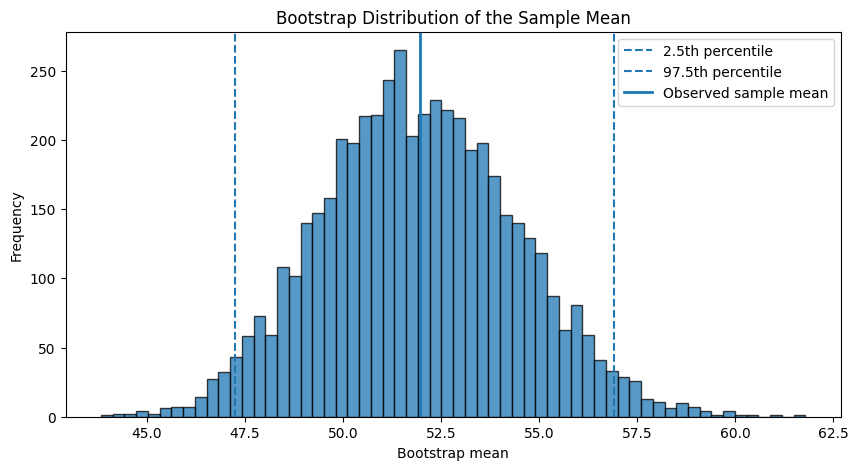

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=60, edgecolor="black", alpha=0.75)
plt.axvline(mean_ci[0], linestyle="--", label="2.5th percentile")
plt.axvline(mean_ci[1], linestyle="--", label="97.5th percentile")
plt.axvline(
    bootstrap_original.mean(),
    linestyle="-",
    linewidth=2,
    label="Observed sample mean"
)
plt.title("Bootstrap Distribution of the Sample Mean")
plt.xlabel("Bootstrap mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Bootstrap thinking template

When you see a custom statistic, ask:

1. What statistic am I estimating?
2. Is the original sample representative?
3. What resampling unit preserves the data structure?
4. Should I resample individual rows, users, groups, time blocks, or folds?
5. How many bootstrap repetitions are sufficient?
6. Which bootstrap interval method is suitable?

For dependent data, ordinary row-level bootstrap may be invalid.  
Time series and grouped data may require block or cluster bootstrap.

# 14. Hypothesis Testing — The Core Mental Model

A hypothesis test asks:

> If a particular population claim were true, would our observed sample result be ordinary or surprisingly extreme?

The process is:

```text
Assume H0 is true
      ↓
Determine how the statistic should vary under H0
      ↓
Measure how far the observed statistic is from H0
      ↓
Calculate the probability of this result or something more extreme
      ↓
Make a decision using alpha
```

---

## Null hypothesis \(H_0\)

The default claim used to construct the reference distribution.

Typical forms:

\[
H_0:\mu=50
\]

\[
H_0:\mu_A=\mu_B
\]

\[
H_0:p_A=p_B
\]

\[
H_0:\text{two categorical variables are independent}
\]

## Alternative hypothesis \(H_1\)

The competing claim.

Two-sided:

\[
H_1:\mu\neq50
\]

One-sided:

\[
H_1:\mu>50
\]

or:

\[
H_1:\mu<50
\]

The alternative must be selected from the research question before inspecting the result.

# 15. What Does a Test Statistic Tell Us?

A test statistic converts an observed difference into standardized units.

The general structure is:

\[
\text{test statistic}
=
\frac{\text{observed estimate}-\text{null value}}
{\text{standard error under the test}}
\]

For a one-sample t-test:

\[
t=
\frac{\bar{x}-\mu_0}
{s/\sqrt n}
\]

---

## Meaning of the sign

- \(t>0\): observed sample mean is above the null value.
- \(t<0\): observed sample mean is below the null value.

## Meaning of the magnitude

- \(t=0\): sample result exactly matches the null value.
- \(t=1\): sample result is one standard error away.
- \(t=-3\): sample result is three standard errors below.
- Large \(|t|\): result is difficult to explain under \(H_0\).
- Small \(|t|\): result is close to what \(H_0\) predicts.

---

## Example: \(t=-9.774\)

This means:

> The observed result is 9.774 standard errors below the null-hypothesis value.

The negative sign describes direction.  
The magnitude describes standardized distance.

It does not directly tell the raw difference or practical importance.

# 16. What Does the p-Value Tell Us?

A p-value is:

> Assuming the null hypothesis is true, the probability of observing a test statistic at least as extreme as the one obtained.

For a two-sided test, “extreme” includes both directions.

---

## What a small p-value means

The observed result would be unusual if \(H_0\) were true.

Therefore, the data provide evidence against \(H_0\).

## What a large p-value means

The result is not sufficiently unusual under \(H_0\).

Therefore, we do not have enough evidence to reject \(H_0\).

---

## What a p-value does not tell us

It is not:

- the probability that \(H_0\) is true;
- the probability that the result occurred “by chance”;
- the size of the effect;
- the probability that the study will replicate;
- proof that the alternative is true.

---

## Memory line

> **p-value = surprise of the data under \(H_0\), not probability of \(H_0\).**

# 17. Fully Worked One-Sample t-Test

## Business question

A company claims that average customer satisfaction is 70.

We collect a sample and ask:

> Is the population mean satisfaction different from 70?

## Step 1 — Parameter

\[
\mu=\text{population mean satisfaction}
\]

## Step 2 — Hypotheses

\[
H_0:\mu=70
\]

\[
H_1:\mu\neq70
\]

## Step 3 — Significance level

\[
\alpha=0.05
\]

## Step 4 — Calculate sample estimate and standard error

## Step 5 — Calculate t-statistic

## Step 6 — Calculate p-value

## Step 7 — Make statistical and practical conclusions

In [24]:
# A deterministic sample with mean lower than 70

satisfaction_sample = np.array([
    61, 62, 63, 64, 64, 65, 65, 66, 66, 66,
    67, 67, 67, 68, 68, 68, 69, 69, 69, 70,
    63, 64, 65, 66, 67, 68, 64, 65, 66, 67
], dtype=float)

claimed_mean = 70.0

x_bar = satisfaction_sample.mean()
s = satisfaction_sample.std(ddof=1)
n = len(satisfaction_sample)
se = s / np.sqrt(n)

t_manual = (x_bar - claimed_mean) / se

t_scipy, p_value = ttest_1samp(
    satisfaction_sample,
    popmean=claimed_mean
)

print("Sample size:", n)
print("Sample mean:", round(x_bar, 3))
print("Claimed mean:", claimed_mean)
print("Raw difference:", round(x_bar - claimed_mean, 3))
print("Sample standard deviation:", round(s, 3))
print("Standard error:", round(se, 3))
print("Manual t-statistic:", round(t_manual, 3))
print("SciPy t-statistic:", round(t_scipy, 3))
print("Two-sided p-value:", f"{p_value:.8f}")

Sample size: 30
Sample mean: 65.967
Claimed mean: 70.0
Raw difference: -4.033
Sample standard deviation: 2.22
Standard error: 0.405
Manual t-statistic: -9.95
SciPy t-statistic: -9.95
Two-sided p-value: 0.00000000


## How to interpret this output

### Raw difference

\[
\bar{x}-\mu_0
\]

This tells the difference in the original measurement units.

### t-statistic

\[
t=\frac{\bar{x}-\mu_0}{SE}
\]

This tells how many standard errors the sample mean is from the null value.

A negative t-statistic means the sample mean is below 70.

### p-value

The p-value tells how likely a result this far from 70—or farther—would be if the true population mean were actually 70.

If \(p<0.05\), reject \(H_0\).

---

## Complete conclusion template

> The sample mean was ___, compared with the null value of ___. The estimated difference was ___ units. The t-statistic was ___, meaning the sample mean was ___ standard errors [above/below] the null value. Because \(p\) was [below/above] 0.05, we [reject/fail to reject] \(H_0\). The data [provide/do not provide] sufficient evidence that the population mean differs from ___. The practical size and context of the difference should also be considered.

In [25]:
alpha = 0.05

if p_value < alpha:
    statistical_decision = "Reject H0"
    evidence_statement = (
        "The sample provides evidence that the population mean differs from 70."
    )
else:
    statistical_decision = "Fail to reject H0"
    evidence_statement = (
        "The sample does not provide sufficient evidence that the "
        "population mean differs from 70."
    )

print("Decision:", statistical_decision)
print("Interpretation:", evidence_statement)

Decision: Reject H0
Interpretation: The sample provides evidence that the population mean differs from 70.


# 18. Alpha and Decision Rules

The significance level \(\alpha\) is chosen before analyzing the data.

Common choice:

\[
\alpha=0.05
\]

Decision rule:

- if \(p<\alpha\), reject \(H_0\);
- if \(p\geq\alpha\), fail to reject \(H_0\).

---

## What does \(\alpha=0.05\) control?

Under repeated use of the testing procedure, when \(H_0\) is true, the long-run probability of a Type I error is limited to approximately 5%, assuming the model and assumptions are correct.

It does not mean:

- every result has exactly a 5% chance of being wrong;
- \(H_0\) has a 5% probability of being true;
- 95% of significant findings are true.

# 19. Type I and Type II Errors

Every hypothesis test can make two kinds of mistakes.

| Reality | Reject \(H_0\) | Fail to reject \(H_0\) |
|---|---|---|
| \(H_0\) true | Type I error | Correct |
| \(H_1\) true | Correct | Type II error |

## Type I error — false positive

We claim an effect exists when it does not.

Medicine example:

> We conclude the medicine works, but it actually has no effect.

ML example:

> We conclude Model B is better, but the observed improvement was sampling noise.

## Type II error — false negative

We miss a real effect.

Medicine example:

> The medicine truly works, but the study fails to detect it.

ML example:

> Model B is genuinely better, but the test set is too small to detect the improvement.

---

## Memory

- Type I = false alarm
- Type II = missed effect

# 20. Statistical Power

Power is:

\[
P(\text{reject }H_0\mid H_1\text{ is true})
\]

It is the probability that a test detects a real effect.

Power tends to increase when:

- sample size increases;
- true effect size increases;
- measurement noise decreases;
- study design becomes more efficient;
- paired information is used correctly;
- alpha increases, although this also increases false-positive risk.

A non-significant result from a low-power study does not establish “no effect.”

In [26]:
effect_sizes = [0.0, 0.25, 0.5, 0.75, 1.0]
sample_sizes_for_power = [30, 100, 300]
power_records = []

for n_current in sample_sizes_for_power:
    for effect in effect_sizes:
        significant_count = 0
        repetitions = 500

        for _ in range(repetitions):
            group_a = rng.normal(50, 10, n_current)
            group_b = rng.normal(50 + effect, 10, n_current)

            _, p = ttest_ind(
                group_a,
                group_b,
                equal_var=False
            )

            if p < 0.05:
                significant_count += 1

        power_records.append({
            "sample_size_per_group": n_current,
            "true_mean_difference": effect,
            "estimated_detection_rate": significant_count / repetitions
        })

power_df = pd.DataFrame(power_records)
power_df

,sample_size_per_group,true_mean_difference,estimated_detection_rate
0,30,0.0000,0.0540
1,30,0.2500,0.0360
2,30,0.5000,0.0480
3,30,0.7500,0.0620
4,30,1.0000,0.0580
5,100,0.0000,0.0540
6,100,0.2500,0.0640
7,100,0.5000,0.0500
8,100,0.7500,0.0720
9,100,1.0000,0.0880


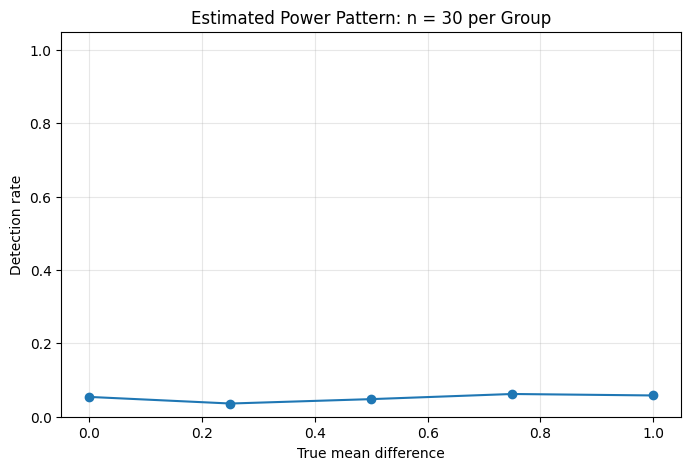

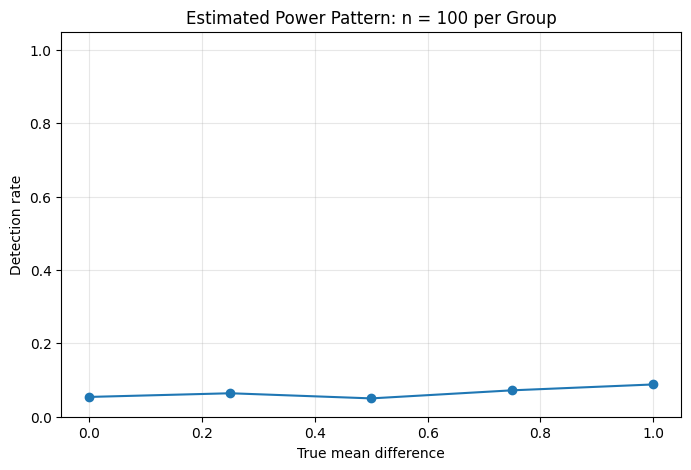

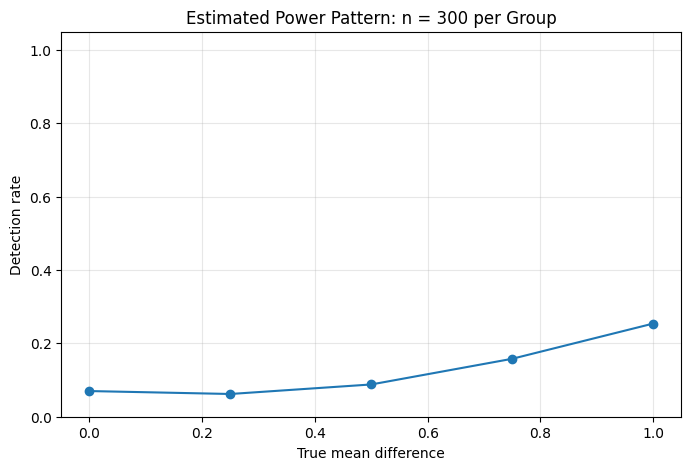

In [27]:
for current_n in sample_sizes_for_power:
    subset = power_df[
        power_df["sample_size_per_group"] == current_n
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(
        subset["true_mean_difference"],
        subset["estimated_detection_rate"],
        marker="o"
    )
    plt.title(f"Estimated Power Pattern: n = {current_n} per Group")
    plt.xlabel("True mean difference")
    plt.ylabel("Detection rate")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.show()

# 21. One-Sided versus Two-Sided Tests

## Two-sided alternative

\[
H_1:\mu\neq\mu_0
\]

Use when either direction matters.

Question:

> Is the mean different?

## Right-sided alternative

\[
H_1:\mu>\mu_0
\]

Use when only an increase is the research claim.

Question:

> Is the mean greater?

## Left-sided alternative

\[
H_1:\mu<\mu_0
\]

Use when only a decrease is the research claim.

---

## Important rule

Choose the direction before seeing the data.

Do not switch from a two-sided test to a one-sided test merely to obtain a smaller p-value.

In [28]:
two_sided = ttest_1samp(
    satisfaction_sample,
    popmean=70,
    alternative="two-sided"
)

less_test = ttest_1samp(
    satisfaction_sample,
    popmean=70,
    alternative="less"
)

greater_test = ttest_1samp(
    satisfaction_sample,
    popmean=70,
    alternative="greater"
)

pd.DataFrame({
    "alternative": ["two-sided", "less", "greater"],
    "t_statistic": [
        two_sided.statistic,
        less_test.statistic,
        greater_test.statistic
    ],
    "p_value": [
        two_sided.pvalue,
        less_test.pvalue,
        greater_test.pvalue
    ]
})

,alternative,t_statistic,p_value
0,two-sided,-9.9496,0.0000
1,less,-9.9496,0.0000
2,greater,-9.9496,1.0000


# 22. Relationship Between a Confidence Interval and a Hypothesis Test

For a two-sided test at \(\alpha=0.05\):

- if the null value lies outside the 95% confidence interval, reject \(H_0\);
- if the null value lies inside the 95% confidence interval, fail to reject \(H_0\).

This works because both procedures use the same sampling distribution and uncertainty.

---

## Why report both?

The p-value helps answer:

> Is the result difficult to explain under \(H_0\)?

The confidence interval helps answer:

> What effect sizes remain plausible?

The interval contains information about both statistical uncertainty and practical magnitude.

In [29]:
one_sample_ci = t.interval(
    confidence=0.95,
    df=n - 1,
    loc=x_bar,
    scale=se
)

print("95% confidence interval:", tuple(np.round(one_sample_ci, 3)))
print("Null value:", claimed_mean)
print(
    "Does CI contain null value?",
    one_sample_ci[0] <= claimed_mean <= one_sample_ci[1]
)
print("Two-sided p-value:", p_value)

95% confidence interval: (np.float64(65.138), np.float64(66.796))
Null value: 70.0
Does CI contain null value? False
Two-sided p-value: 7.400294749659472e-11


# 23. Independent Two-Sample t-Test

Use this test when:

- the outcome is numerical;
- there are two separate groups;
- observations in one group are not paired with observations in the other.

Examples:

- treatment group versus placebo group;
- customers seeing Website A versus different customers seeing Website B;
- two independent classrooms;
- two different production methods.

Hypotheses:

\[
H_0:\mu_A=\mu_B
\]

\[
H_1:\mu_A\neq\mu_B
\]

---

## Welch's t-test

In most practical cases, use:

```python
ttest_ind(group_a, group_b, equal_var=False)
```

This is Welch's t-test. It does not assume equal population variances.

Important assumptions still include:

- independent observations;
- meaningful numerical outcome;
- representative sampling or random assignment;
- no destructive outliers for small samples;
- approximate normality within groups for small samples, or adequate sample sizes.

In [30]:
medicine_group = np.array([
    78, 82, 85, 80, 88, 79, 84, 86, 81, 83,
    87, 80, 82, 84, 85, 79, 86, 88, 83, 82
], dtype=float)

placebo_group = np.array([
    70, 72, 69, 74, 71, 73, 68, 72, 75, 70,
    71, 69, 74, 72, 70, 73, 68, 71, 72, 69
], dtype=float)

ind_result = ttest_ind(
    medicine_group,
    placebo_group,
    equal_var=False
)

mean_medicine = medicine_group.mean()
mean_placebo = placebo_group.mean()
raw_difference = mean_medicine - mean_placebo

print("Medicine mean:", round(mean_medicine, 3))
print("Placebo mean:", round(mean_placebo, 3))
print("Observed difference:", round(raw_difference, 3))
print("Welch t-statistic:", round(ind_result.statistic, 3))
print("p-value:", f"{ind_result.pvalue:.8f}")

Medicine mean: 83.1
Placebo mean: 71.15
Observed difference: 11.95
Welch t-statistic: 14.606
p-value: 0.00000000


## How to read the sign

SciPy computes:

\[
\bar{x}_{first}-\bar{x}_{second}
\]

Therefore:

- positive t → first group's mean is higher;
- negative t → first group's mean is lower.

Always inspect the order of the function arguments before interpreting direction.

## What is a placebo?

A placebo is an inactive treatment designed to resemble the real treatment.

Example:

- treatment group receives the active medicine;
- placebo group receives a visually similar inactive pill.

Why use it?

People can improve because of:

- expectation;
- attention from researchers;
- natural recovery;
- regression toward typical values;
- other changes unrelated to the active ingredient.

Comparing treatment with placebo helps isolate the active treatment's effect.

The **placebo effect** is improvement related to expectations or treatment context rather than the active medical ingredient.

# 24. Paired t-Test

Use a paired t-test when measurements are naturally matched.

Examples:

- same people before and after treatment;
- same users under two interfaces;
- same ML folds used for two models;
- matched twins or matched stores.

The test does not primarily compare two independent means.

It creates one difference per pair:

\[
d_i=\text{after}_i-\text{before}_i
\]

Then it tests:

\[
H_0:\mu_d=0
\]

The normality assumption, especially for small samples, applies to the **differences**, not necessarily to the two original columns separately.

In [31]:
before = np.array([
    85, 90, 78, 88, 92, 81, 87, 89, 84, 91,
    86, 80, 93, 88, 85
], dtype=float)

after = np.array([
    78, 84, 75, 80, 86, 77, 82, 84, 79, 85,
    81, 76, 87, 83, 80
], dtype=float)

differences = after - before

paired_result = ttest_rel(after, before)

print("Before mean:", round(before.mean(), 3))
print("After mean:", round(after.mean(), 3))
print("Mean difference (after - before):", round(differences.mean(), 3))
print("Paired t-statistic:", round(paired_result.statistic, 3))
print("p-value:", f"{paired_result.pvalue:.8f}")

Before mean: 86.467
After mean: 81.133
Mean difference (after - before): -5.333
Paired t-statistic: -16.733
p-value: 0.00000000


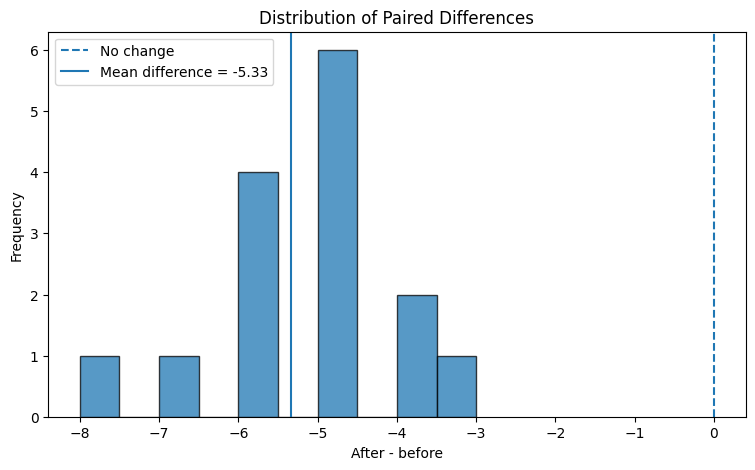

In [32]:
plt.figure(figsize=(9, 5))
plt.hist(differences, bins=10, edgecolor="black", alpha=0.75)
plt.axvline(0, linestyle="--", label="No change")
plt.axvline(
    differences.mean(),
    linestyle="-",
    label=f"Mean difference = {differences.mean():.2f}"
)
plt.title("Distribution of Paired Differences")
plt.xlabel("After - before")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Common mistake

Using an independent t-test for before/after data throws away the pairing.

The paired design can be more powerful because each subject acts as their own comparison.

# 25. What If Mean-Based Assumptions Are Poor?

Normality of raw data is not always required.

For large independent samples, the Central Limit Theorem often supports mean-based inference.

For small samples with extreme skewness or destructive outliers, alternatives may include:

| Situation | Possible method |
|---|---|
| One-sample or paired non-normal data | Wilcoxon signed-rank test |
| Two independent non-normal groups | Mann–Whitney U test |
| Difficult statistic | Bootstrap or permutation test |
| Strong positive skew | Domain-appropriate log transformation |
| Heavy dependence | Cluster/block methods |

Nonparametric tests answer different questions under different assumptions.  
They are not simply “t-tests without normality.”

In [33]:
# Demonstration only: nonparametric alternatives

mann_whitney_result = mannwhitneyu(
    medicine_group,
    placebo_group,
    alternative="two-sided"
)

wilcoxon_result = wilcoxon(
    after,
    before,
    alternative="two-sided"
)

print("Mann–Whitney U p-value:", mann_whitney_result.pvalue)
print("Wilcoxon signed-rank p-value:", wilcoxon_result.pvalue)

Mann–Whitney U p-value: 6.45816437538523e-08
Wilcoxon signed-rank p-value: 0.0005820971062164764


# 26. Chi-Square Test of Independence

Use this test when both variables are categorical.

Question:

> Are the two categorical variables associated?

Example:

- customer segment: Budget, Regular, Premium;
- churn: Yes, No.

Hypotheses:

\[
H_0:\text{segment and churn are independent}
\]

\[
H_1:\text{segment and churn are associated}
\]

The test compares:

- observed cell counts;
- expected cell counts if the variables were independent.

The chi-square statistic grows when observed counts differ strongly from independence-based expected counts.

In [34]:
contingency_table = pd.DataFrame(
    {
        "No churn": [290, 370, 145],
        "Churn": [110, 80, 15]
    },
    index=["Budget", "Regular", "Premium"]
)

contingency_table

,No churn,Churn
Budget,290,110
Regular,370,80
Premium,145,15


In [35]:
chi2_stat, chi2_p, dof, expected = chi2_contingency(
    contingency_table
)

expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("Chi-square statistic:", round(chi2_stat, 3))
print("Degrees of freedom:", dof)
print("p-value:", f"{chi2_p:.8f}")
print()
print("Expected counts under independence:")
display(expected_df)

Chi-square statistic: 26.392
Degrees of freedom: 2
p-value: 0.00000186

Expected counts under independence:


,No churn,Churn
Budget,318.8119,81.1881
Regular,358.6634,91.3366
Premium,127.5248,32.4752


## How to interpret the result

A small p-value suggests that the observed count pattern would be unusual if segment and churn were independent.

Therefore, we infer evidence of association.

But chi-square does not automatically tell:

- which cells drive the association;
- the strength of association;
- whether segment causes churn.

Inspect proportions, residuals, and effect-size measures such as Cramér's V.

In [36]:
n_total = contingency_table.to_numpy().sum()
r, c = contingency_table.shape

cramers_v = np.sqrt(
    chi2_stat / (n_total * min(r - 1, c - 1))
)

row_proportions = contingency_table.div(
    contingency_table.sum(axis=1),
    axis=0
)

print("Cramér's V:", round(cramers_v, 3))
print()
print("Within-segment proportions:")
row_proportions

Cramér's V: 0.162

Within-segment proportions:


,No churn,Churn
Budget,0.7250,0.2750
Regular,0.8222,0.1778
Premium,0.9062,0.0938


# 27. A/B Testing for Two Conversion Rates

A/B testing compares two randomly assigned versions.

Example:

- A = existing webpage;
- B = redesigned webpage;
- outcome = converted or did not convert.

Parameter of interest:

\[
p_B-p_A
\]

Hypotheses:

\[
H_0:p_A=p_B
\]

\[
H_1:p_A\neq p_B
\]

A complete analysis should report:

1. conversion rate for each group;
2. absolute difference;
3. relative lift where meaningful;
4. confidence interval for the difference;
5. test statistic and p-value;
6. practical impact;
7. data-quality and experiment-validity checks.

In [37]:
n_A = 5_000
n_B = 5_200

success_A = 275
success_B = 338

p_A = success_A / n_A
p_B = success_B / n_B
difference = p_B - p_A

pooled_p = (success_A + success_B) / (n_A + n_B)

se_null = np.sqrt(
    pooled_p * (1 - pooled_p) * (1 / n_A + 1 / n_B)
)

z_stat = difference / se_null
ab_p_value = 2 * norm.sf(abs(z_stat))

# Unpooled standard error for CI of the actual difference
se_difference = np.sqrt(
    p_A * (1 - p_A) / n_A
    + p_B * (1 - p_B) / n_B
)

difference_lower = difference - z_critical * se_difference
difference_upper = difference + z_critical * se_difference

relative_lift = difference / p_A

ab_results = pd.Series({
    "rate_A": p_A,
    "rate_B": p_B,
    "absolute_difference_B_minus_A": difference,
    "relative_lift": relative_lift,
    "z_statistic": z_stat,
    "p_value": ab_p_value,
    "CI_lower_difference": difference_lower,
    "CI_upper_difference": difference_upper
})

ab_results

rate_A                          0.0550
rate_B                          0.0650
absolute_difference_B_minus_A   0.0100
relative_lift                   0.1818
z_statistic                     2.1243
p_value                         0.0336
CI_lower_difference             0.0008
CI_upper_difference             0.0192
dtype: float64

## How to distinguish absolute difference and relative lift

Suppose:

\[
p_A=5.5\%,\qquad p_B=6.5\%
\]

Absolute difference:

\[
6.5\%-5.5\%=1.0\text{ percentage point}
\]

Relative lift:

\[
\frac{6.5\%-5.5\%}{5.5\%}\approx18.2\%
\]

Both are useful, but they answer different questions.

A recommendation must also consider:

- implementation cost;
- revenue per conversion;
- negative side effects;
- novelty effects;
- experiment duration;
- sample-ratio mismatch;
- multiple metrics;
- whether randomization was valid.

# 28. Statistical Significance versus Practical Significance

## Statistical significance

Asks:

> Is the observed result difficult to explain as random sampling variation under \(H_0\)?

## Practical significance

Asks:

> Is the effect large enough to matter?

A tiny difference can become statistically significant with a very large sample.

A meaningful difference can fail to reach significance in a small, noisy study.

Always report:

- effect estimate;
- confidence interval;
- p-value;
- sample size;
- domain-specific practical threshold.

# 29. Multiple Testing

If 100 true null hypotheses are tested at \(\alpha=0.05\), some may appear significant by chance.

The expected number of false positives is approximately:

\[
100\times0.05=5
\]

This does not guarantee exactly five, but it explains the risk.

Common approaches:

- pre-register a primary metric;
- reduce unnecessary testing;
- Bonferroni correction;
- Holm correction;
- false discovery rate procedures;
- validation on new data.

In ML, multiple testing appears when trying:

- many features;
- many models;
- many hyperparameters;
- many subgroups;
- many metrics;
- many time windows.

In [38]:
n_tests = 100
alpha = 0.05

simulated_null_p_values = rng.uniform(
    0,
    1,
    size=n_tests
)

significant_uncorrected = (
    simulated_null_p_values < alpha
).sum()

bonferroni_alpha = alpha / n_tests

significant_bonferroni = (
    simulated_null_p_values < bonferroni_alpha
).sum()

print("Number of tests:", n_tests)
print("Uncorrected alpha:", alpha)
print("Significant without correction:", significant_uncorrected)
print("Bonferroni alpha:", bonferroni_alpha)
print("Significant with Bonferroni:", significant_bonferroni)

Number of tests: 100
Uncorrected alpha: 0.05
Significant without correction: 5
Bonferroni alpha: 0.0005
Significant with Bonferroni: 0


# 30. Statistical Thinking for ML Model Evaluation

A model metric from one test set is a sample estimate of future performance.

Do not ask only:

> Which score is larger?

Also ask:

- How uncertain is each metric?
- Were predictions evaluated on the same observations?
- Is the difference practically meaningful?
- Are results stable across folds or time periods?
- Did model selection repeatedly use the same validation data?
- Is there class imbalance?
- What is the cost of false positives and false negatives?
- Does performance remain stable under distribution shift?

In [39]:
X, y = make_classification(
    n_samples=3_000,
    n_features=12,
    n_informative=7,
    n_redundant=2,
    weights=[0.70, 0.30],
    class_sep=1.0,
    random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1_000))
])

forest_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=7,
    random_state=RANDOM_STATE
)

logistic_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

pred_logistic = logistic_model.predict(X_test)
pred_forest = forest_model.predict(X_test)

metric_table = pd.DataFrame({
    "model": ["Logistic regression", "Random forest"],
    "accuracy": [
        accuracy_score(y_test, pred_logistic),
        accuracy_score(y_test, pred_forest)
    ],
    "f1": [
        f1_score(y_test, pred_logistic),
        f1_score(y_test, pred_forest)
    ]
})

metric_table

,model,accuracy,f1
0,Logistic regression,0.8756,0.7846
1,Random forest,0.9144,0.8451


## Why paired comparison matters

Both models predict the same test observations.

Their prediction errors are therefore paired.

Comparing two independent accuracy confidence intervals ignores this pairing.

For two classifiers on the same test cases, methods such as McNemar's test or paired bootstrap may be more appropriate for direct comparison.

For cross-validation, fold scores are paired by fold, but ordinary paired t-tests over folds are only a simplified teaching approximation because CV folds are not fully independent.

In [40]:
cv = StratifiedKFold(
    n_splits=8,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_logistic = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

cv_forest = cross_val_score(
    forest_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

cv_results = pd.DataFrame({
    "fold": np.arange(1, len(cv_logistic) + 1),
    "logistic_f1": cv_logistic,
    "forest_f1": cv_forest,
    "difference_forest_minus_logistic": (
        cv_forest - cv_logistic
    )
})

cv_results

,fold,logistic_f1,forest_f1,difference_forest_minus_logistic
0,1,0.7619,0.8317,0.0698
1,2,0.7330,0.8077,0.0747
2,3,0.7222,0.8000,0.0778
3,4,0.7488,0.8473,0.0985
4,5,0.7870,0.8612,0.0742
5,6,0.7014,0.8060,0.1045
6,7,0.7411,0.8311,0.0900
7,8,0.7290,0.8654,0.1364


In [41]:
cv_paired_result = ttest_rel(
    cv_forest,
    cv_logistic
)

print("Mean logistic F1:", round(cv_logistic.mean(), 4))
print("Mean forest F1:", round(cv_forest.mean(), 4))
print(
    "Mean paired difference:",
    round((cv_forest - cv_logistic).mean(), 4)
)
print(
    "Teaching paired t-test p-value:",
    round(cv_paired_result.pvalue, 6)
)

Mean logistic F1: 0.7406
Mean forest F1: 0.8313
Mean paired difference: 0.0907
Teaching paired t-test p-value: 8e-06


# 31. Test-Selection Decision System

Start with the outcome type.

## A. Numerical outcome

### One sample compared with a claimed value

Use:

- one-sample t-test;
- bootstrap or robust alternative if assumptions are poor.

### Two separate groups

Use:

- Welch independent t-test;
- Mann–Whitney or permutation method when appropriate.

### Same subjects or matched pairs

Use:

- paired t-test;
- Wilcoxon signed-rank or paired bootstrap when appropriate.

## B. Binary proportion

### One proportion

Use:

- binomial/proportion confidence interval;
- one-proportion test.

### Two independent proportions

Use:

- two-proportion z-test;
- exact methods when counts are small.

## C. Two categorical variables

Use:

- chi-square test of independence;
- Fisher's exact test for small 2×2 tables.

## D. Difficult custom statistic

Use:

- bootstrap;
- permutation test;
- domain-specific method.

---

## Fast memory table

| Question | Typical method |
|---|---|
| One mean versus claimed value | One-sample t-test |
| Two independent means | Welch two-sample t-test |
| Same subjects twice | Paired t-test |
| Two conversion rates | Two-proportion z-test |
| Two categorical variables | Chi-square independence test |
| Uncertainty around a mean | t confidence interval |
| Uncertainty around a proportion | Proportion confidence interval |
| Difficult statistic | Bootstrap |

# 32. Universal Interpretation Templates

## Confidence interval

> The sample estimate was ___. The ___% confidence interval ranged from ___ to ___. This interval describes the uncertainty of the estimation procedure and provides a range of population values compatible with the sample and method assumptions.

## One-sample t-test

> The sample mean was ___ compared with the null value of ___. The estimated difference was ___. The t-statistic was ___, indicating that the sample mean was ___ standard errors [above/below] the null value. The p-value was ___. At \(\alpha=___\), we [reject/fail to reject] \(H_0\). The data [provide/do not provide] sufficient evidence that the population mean differs from ___.

## Independent t-test

> Group A had mean ___ and Group B had mean ___. The observed difference \(A-B\) was ___. Welch's t-test produced \(t=___\) and \(p=___\). At \(\alpha=___\), we [reject/fail to reject] the equal-means null hypothesis. The estimated magnitude and confidence interval should be considered for practical importance.

## Paired t-test

> The mean paired change was ___. The paired t-statistic was ___ and the p-value was ___. The result [does/does not] provide sufficient evidence that the population mean difference is nonzero.

## Chi-square test

> The chi-square test produced \(\chi^2=___\), \(df=___\), and \(p=___\). We [reject/fail to reject] the independence null hypothesis. This indicates [evidence/no sufficient evidence] of association, not necessarily causation.

## A/B test

> Group A converted at ___% and Group B at ___%. The absolute difference was ___ percentage points and the relative lift was ___%. The confidence interval for \(p_B-p_A\) was ___. The two-proportion test produced \(z=___\) and \(p=___\). Statistical evidence, practical value, experiment validity, and implementation cost should all inform the decision.

# 33. Common Mistakes and Corrections

## Mistake 1

> “The p-value is the probability that \(H_0\) is true.”

Correction:

> The p-value assumes \(H_0\) is true and measures how extreme the observed result is under that assumption.

## Mistake 2

> “Fail to reject \(H_0\) proves no effect.”

Correction:

> It means the data did not provide enough evidence against \(H_0\). The study may have low power.

## Mistake 3

> “A significant result must be important.”

Correction:

> Statistical significance does not measure practical magnitude.

## Mistake 4

> “The data must always be normally distributed.”

Correction:

> The relevant sampling distribution may be approximately normal for sufficiently large samples. Small, highly skewed, or heavy-tailed samples require more care.

## Mistake 5

> “A confidence interval uses the mean of many real samples.”

Correction:

> It uses the mean from one observed sample. The sampling distribution tells us how uncertain that mean is.

## Mistake 6

> “The confidence interval calculates the center.”

Correction:

> The sample estimate is the center. The interval adds and subtracts uncertainty.

## Mistake 7

> “A negative t-value means a bad result.”

Correction:

> The sign only describes direction relative to the subtraction order.

## Mistake 8

> “Overlapping confidence intervals prove no significant difference.”

Correction:

> Direct group comparison requires the standard error of the difference or an appropriate paired test.

## Mistake 9

> “Bootstrap fixes a biased sample.”

Correction:

> Bootstrap resamples the observed sample and can reproduce its bias.

## Mistake 10

> “Run many tests and report only significant ones.”

Correction:

> This inflates false discoveries and creates selective-reporting bias.

# 34. The “Solve Anything” Workflow

Use this every time.

## 1. Write the research question in plain language

Example:

> Did the same patients' blood pressure decrease after treatment?

## 2. Identify the parameter

\[
\mu_d=\text{population mean of after-before differences}
\]

## 3. Identify the data structure

- numerical outcome;
- same patients twice;
- paired observations.

## 4. Choose estimation and/or test

- confidence interval for mean paired difference;
- paired t-test.

## 5. Write hypotheses

\[
H_0:\mu_d=0
\]

\[
H_1:\mu_d<0
\]

if the decrease direction was specified in advance.

## 6. Check assumptions and data quality

- correct pairing;
- independent pairs;
- no severe data errors;
- difference distribution reasonable for sample size.

## 7. Calculate descriptive statistics first

- sample size;
- mean difference;
- standard deviation of differences;
- plot of differences.

## 8. Calculate uncertainty

\[
SE_{\bar d}=\frac{s_d}{\sqrt n}
\]

## 9. Calculate interval and test

- confidence interval;
- t-statistic;
- p-value.

## 10. Interpret in original units

Do not stop at “significant.”

State:

- direction;
- magnitude;
- uncertainty;
- decision;
- practical meaning;
- limitations.

# 35. Guided Practice — Think Before Running Code

For each problem:

1. identify the parameter;
2. identify the data structure;
3. choose a method;
4. write \(H_0\) and \(H_1\);
5. state assumptions;
6. interpret the possible output.

Write your answers in the empty cells.

## Practice 1 — One population mean

A delivery company claims that its average delivery time is 30 minutes.  
A random sample of 60 deliveries has mean 33.2 minutes and standard deviation 8.5 minutes.

Answer:

1. What is the parameter?
2. Write two-sided hypotheses.
3. What test is appropriate?
4. Calculate the standard error.
5. Calculate the t-statistic.
6. Explain the sign and magnitude.
7. What additional information is needed for the final decision?

In [42]:
# Practice 1 workspace

sample_mean = 33.2
claimed_mean = 30
sample_std = 8.5
sample_size = 60

# Write your calculations below

<details>
<summary><strong>Reveal Practice 1 reasoning</strong></summary>

Parameter:

\[
\mu=\text{true mean delivery time}
\]

Hypotheses:

\[
H_0:\mu=30
\]

\[
H_1:\mu\neq30
\]

Method: one-sample t-test.

Standard error:

\[
SE=\frac{8.5}{\sqrt{60}}
\]

Test statistic:

\[
t=\frac{33.2-30}{SE}
\]

The sign is positive because the observed mean is above 30.  
The magnitude tells how many standard errors the observed mean is from the claim.

The degrees of freedom and t distribution are used to calculate the p-value.

</details>

## Practice 2 — Independent groups

A medicine group and placebo group contain different patients.  
The outcome is a numerical symptom score.

Answer:

1. Independent or paired?
2. What test?
3. What does a negative t-statistic mean if the function receives `(medicine, placebo)`?
4. Why is `equal_var=False` often preferred?
5. What effect estimate should be reported?

<details>
<summary><strong>Reveal Practice 2 reasoning</strong></summary>

The groups are independent because they contain different patients.

Use Welch's independent two-sample t-test.

If SciPy receives `(medicine, placebo)`, a negative t-statistic means:

\[
\bar{x}_{medicine}<\bar{x}_{placebo}
\]

`equal_var=False` uses Welch's test and does not assume equal population variances.

Report the raw mean difference and preferably a confidence interval, not only the p-value.

</details>

## Practice 3 — Paired measurements

The same 25 students take a test before and after a course.

Answer:

1. What variable should be analyzed?
2. What is the null parameter value?
3. Which test?
4. Which distribution should be checked for a small sample?
5. Why is an independent test inappropriate?

<details>
<summary><strong>Reveal Practice 3 reasoning</strong></summary>

Create one difference per student:

\[
d_i=after_i-before_i
\]

Test:

\[
H_0:\mu_d=0
\]

Use a paired t-test.

For a small sample, inspect the distribution of the differences.

An independent test ignores the matching and overstates unexplained variation.

</details>

## Practice 4 — Conversion experiment

Website A has 500 conversions from 10,000 visitors.  
Website B has 575 conversions from 10,000 visitors.

Answer:

1. Calculate each conversion rate.
2. Calculate the absolute percentage-point difference.
3. Calculate relative lift.
4. State hypotheses.
5. Choose a test.
6. Explain why business value cannot be decided from the p-value alone.

In [43]:
# Practice 4 workspace

success_A = 500
total_A = 10_000

success_B = 575
total_B = 10_000

# Write your calculations below

<details>
<summary><strong>Reveal Practice 4 reasoning</strong></summary>

\[
\hat p_A=500/10000=0.05
\]

\[
\hat p_B=575/10000=0.0575
\]

Absolute difference:

\[
0.0575-0.05=0.0075
\]

This is 0.75 percentage points.

Relative lift:

\[
0.0075/0.05=0.15=15\%
\]

Hypotheses:

\[
H_0:p_A=p_B
\]

\[
H_1:p_A\neq p_B
\]

Use a two-proportion z-test, assuming independent randomized groups and adequate counts.

Business value also depends on revenue, implementation cost, customer impact, and experiment validity.

</details>

## Practice 5 — Categorical association

You have a table of customer segment by churn status.

Answer:

1. What is the null hypothesis?
2. What test?
3. What are expected counts?
4. What does a small p-value establish?
5. What does it not establish?

<details>
<summary><strong>Reveal Practice 5 reasoning</strong></summary>

Null hypothesis:

> Segment and churn are independent.

Use a chi-square test of independence.

Expected counts are the counts predicted in each cell if row and column variables were independent.

A small p-value provides evidence of association.

It does not establish causation or identify the exact practical mechanism.

</details>

# 36. Mini Project — Complete Statistical Investigation

Choose one scenario:

- customer spending;
- A/B conversion experiment;
- before/after intervention;
- ML model comparison.

## Required report structure

### Part 1 — Question

State the population question in one sentence.

### Part 2 — Parameter

Define the population quantity mathematically and in words.

### Part 3 — Data structure

State:

- outcome type;
- number of groups;
- independent or paired;
- sample sizes.

### Part 4 — Descriptive analysis

Include:

- means/proportions;
- standard deviations where relevant;
- raw difference;
- plots;
- missing values and suspicious observations.

### Part 5 — Assumptions

Explain why the selected method is or is not reasonable.

### Part 6 — Confidence interval

Report:

- estimate;
- standard error;
- critical value;
- margin of error;
- lower and upper bounds;
- interpretation.

### Part 7 — Hypothesis test

Report:

- \(H_0\);
- \(H_1\);
- alpha;
- test statistic;
- direction;
- p-value;
- decision.

### Part 8 — Practical significance

Explain whether the estimated effect matters in the real application.

### Part 9 — Errors and limitations

Discuss:

- Type I risk;
- Type II risk;
- sample representativeness;
- power;
- multiple testing;
- possible confounding or data leakage.

### Part 10 — Final recommendation

Write one paragraph that a manager or ML engineer can act on.

In [44]:
# Mini-project workspace

# 1. Load or simulate data
# 2. Inspect data
# 3. Define parameter
# 4. Calculate descriptive statistics
# 5. Plot distributions
# 6. Calculate confidence interval
# 7. Run hypothesis test
# 8. Interpret statistical and practical significance

# 37. Final Mastery Checklist

You understand this notebook when you can explain all of these without memorized wording:

- [ ] Why sample results vary
- [ ] Difference between population, parameter, sample, and statistic
- [ ] Difference between data distribution and sampling distribution
- [ ] Difference between standard deviation and standard error
- [ ] What the Central Limit Theorem makes approximately normal
- [ ] Why CLT supports many mean-based confidence intervals and tests
- [ ] Why one sample mean is the center of a confidence interval
- [ ] What controls interval width
- [ ] Correct meaning of 95% confidence
- [ ] How bootstrap resampling works
- [ ] Meaning of \(H_0\) and \(H_1\)
- [ ] Meaning of a t-statistic
- [ ] Meaning and non-meaning of a p-value
- [ ] Difference between reject and fail to reject
- [ ] Type I and Type II errors
- [ ] Statistical power
- [ ] One-sided versus two-sided tests
- [ ] One-sample, independent, and paired t-tests
- [ ] Chi-square test of independence
- [ ] Two-proportion A/B testing
- [ ] Statistical versus practical significance
- [ ] Multiple-testing risk
- [ ] How to communicate a complete conclusion

# 38. The Entire Notebook in Six Sentences

1. A sample statistic changes from sample to sample because of sampling variation.  
2. A sampling distribution describes that change, and its spread is measured by standard error.  
3. The Central Limit Theorem often makes the sampling distribution of a sufficiently large sample mean approximately normal, even when individual data are skewed.  
4. A confidence interval uses one observed estimate plus and minus a margin of error to represent plausible population values.  
5. A hypothesis test assumes \(H_0\), measures the observed result in standard-error units, and uses the p-value to quantify how surprising that result is under \(H_0\).  
6. A strong statistical conclusion reports the effect, uncertainty, p-value, assumptions, practical importance, and limitations—not merely “significant” or “not significant.”